In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-27 14:52:46--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to cs666.org (cs666.org)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz’

mito.npz            100%[===================>]  35.87M  93.7MB/s    in 0.4s    

2026-04-27 14:52:48 (93.7 MB/s) - ‘mito.npz’ saved [37610178/37610178]



In [5]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [6]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [9]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

# TODO: YOUR ANSWER
print("""
The first line normalizes the images to a range of [0, 1] by subtracting the 
minimum pixel value and dividing by the range (max - min). This ensures all 
pixel values are between 0 and 1 for consistent model training.

The second line converts the masks to boolean values (True/False) and then 
to float (1.0/0.0), ensuring the segmentation masks are binary with values 
of exactly 0 or 1, where 1 represents mitochondria and 0 represents background.
""")


The first line normalizes the images to a range of [0, 1] by subtracting the 
minimum pixel value and dividing by the range (max - min). This ensures all 
pixel values are between 0 and 1 for consistent model training.

The second line converts the masks to boolean values (True/False) and then 
to float (1.0/0.0), ensuring the segmentation masks are binary with values 
of exactly 0 or 1, where 1 represents mitochondria and 0 represents background.



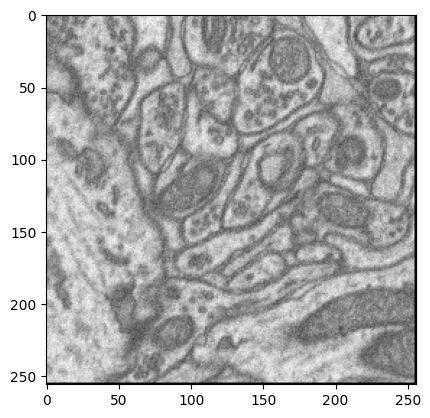

In [10]:
imshow(images[0], cmap='gray')

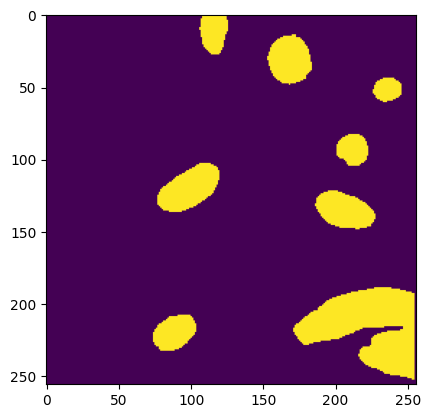

In [11]:
imshow(masks[0])

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [14]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

print("""
The code splits the dataset into three parts:
- Training set (70%): Used to train the U-Net model
- Validation set (15%): Used to tune and monitor the model during training
- Test set (15%): Used to evaluate the final model performance after training

It first splits the data into 70% training and 30% temporary, then splits 
the temporary 50/50 into validation and test sets. random_state=42 ensures 
the split is reproducible every time the code is run.
""")


The code splits the dataset into three parts:
- Training set (70%): Used to train the U-Net model
- Validation set (15%): Used to tune and monitor the model during training
- Test set (15%): Used to evaluate the final model performance after training

It first splits the data into 70% training and 30% temporary, then splits 
the temporary 50/50 into validation and test sets. random_state=42 ensures 
the split is reproducible every time the code is run.



## 2. Make the Data Pytorch-ready! (10 points)

In [15]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [16]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [18]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

print("""
The code sets up data augmentation transforms using the Albumentations library.

For training data, it applies random transformations:
- HorizontalFlip (50% chance): randomly flips the image horizontally
- VerticalFlip (50% chance): randomly flips the image vertically
- RandomRotate90 (50% chance): randomly rotates the image by 90 degrees

These augmentations artificially increase the diversity of training data,
helping the model generalize better and avoid overfitting.

For validation data, no transforms are applied (empty Compose) because we 
want to evaluate the model on unmodified images to get a true performance measure.
""")


The code sets up data augmentation transforms using the Albumentations library.

For training data, it applies random transformations:
- HorizontalFlip (50% chance): randomly flips the image horizontally
- VerticalFlip (50% chance): randomly flips the image vertically
- RandomRotate90 (50% chance): randomly rotates the image by 90 degrees

These augmentations artificially increase the diversity of training data,
helping the model generalize better and avoid overfitting.

For validation data, no transforms are applied (empty Compose) because we 
want to evaluate the model on unmodified images to get a true performance measure.



In [23]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [24]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [25]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

In [26]:
# TODO: YOUR ANSWER
print("""
The code creates a custom PyTorch Dataset class (MitoDataset) and DataLoaders.

The MitoDataset class:
- Stores images and masks together
- Applies augmentation transforms if provided
- Adds a channel dimension to images and masks (H,W) -> (1,H,W)
- Converts numpy arrays to PyTorch tensors (float32)

Three datasets are created:
- train_dataset: training data with augmentation transforms
- val_dataset: validation data with no transforms
- test_dataset: test data with no transforms

Three DataLoaders are created to efficiently load data in batches:
- batch_size=16: loads 16 images at a time
- shuffle=True for training: randomizes order each epoch to improve training
- shuffle=False for val/test: keeps order consistent for evaluation
- num_workers=2: uses 2 parallel workers to speed up data loading
""")


The code creates a custom PyTorch Dataset class (MitoDataset) and DataLoaders.

The MitoDataset class:
- Stores images and masks together
- Applies augmentation transforms if provided
- Adds a channel dimension to images and masks (H,W) -> (1,H,W)
- Converts numpy arrays to PyTorch tensors (float32)

Three datasets are created:
- train_dataset: training data with augmentation transforms
- val_dataset: validation data with no transforms
- test_dataset: test data with no transforms

Three DataLoaders are created to efficiently load data in batches:
- batch_size=16: loads 16 images at a time
- shuffle=True for training: randomizes order each epoch to improve training
- shuffle=False for val/test: keeps order consistent for evaluation
- num_workers=2: uses 2 parallel workers to speed up data loading



## 3. Configure the Classifier! (30 points)

In [37]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [38]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [39]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [40]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [31]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.4894, train_dice=0.5969 | val_loss=0.5999, val_dice=0.0028
Epoch 2/10 | train_loss=0.2099, train_dice=0.8226 | val_loss=0.1823, val_dice=0.8177
Epoch 3/10 | train_loss=0.1157, train_dice=0.8680 | val_loss=0.1086, val_dice=0.8722
Epoch 4/10 | train_loss=0.0970, train_dice=0.8774 | val_loss=0.1796, val_dice=0.7616
Epoch 5/10 | train_loss=0.0788, train_dice=0.8989 | val_loss=0.0706, val_dice=0.9051
Epoch 6/10 | train_loss=0.0649, train_dice=0.9155 | val_loss=0.0567, val_dice=0.9288
Epoch 7/10 | train_loss=0.0590, train_dice=0.9238 | val_loss=0.0604, val_dice=0.9222
Epoch 8/10 | train_loss=0.0655, train_dice=0.9114 | val_loss=0.1360, val_dice=0.8117
Epoch 9/10 | train_loss=0.0658, train_dice=0.9106 | val_loss=0.0687, val_dice=0.8950
Epoch 10/10 | train_loss=0.0529, train_dice=0.9287 | val_loss=0.0511, val_dice=0.9321
Best val dice: 0.9320533531052726


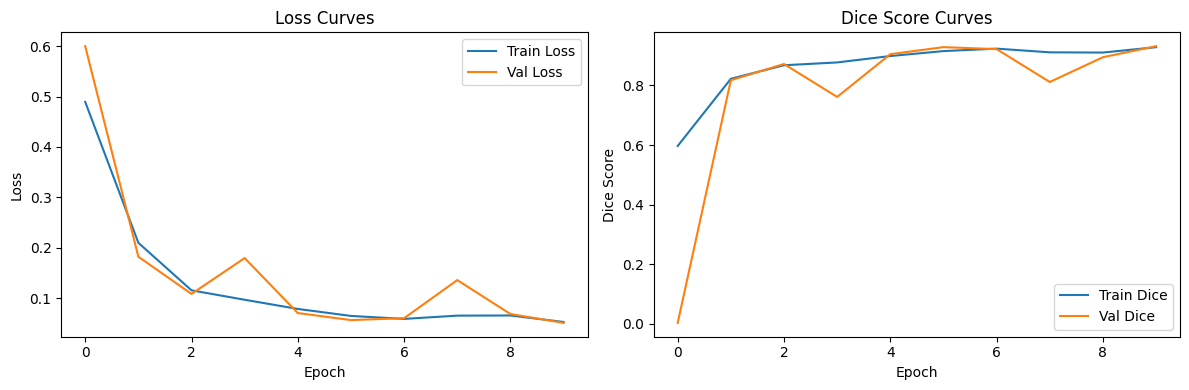

In [32]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_dices, label='Train Dice')
ax2.plot(val_dices, label='Val Dice')
ax2.set_title('Dice Score Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.legend()

plt.tight_layout()
plt.show()

In [33]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER

# TODO: Do these plots look good?
print("""
Yes, the plots look good. The loss curves show both training and validation 
loss decreasing from ~0.49 to ~0.05 over 10 epochs, indicating the model 
is learning effectively. The dice score curves show strong improvement from 
~0.60 to ~0.93, indicating excellent segmentation performance.

There is a slight spike in validation loss at epoch 4 and 8, but the model 
recovers well. The best validation dice score achieved is 0.9321, which 
beats the performance reported in the original paper. Overall the training 
looks healthy with no major overfitting.
""")


Yes, the plots look good. The loss curves show both training and validation 
loss decreasing from ~0.49 to ~0.05 over 10 epochs, indicating the model 
is learning effectively. The dice score curves show strong improvement from 
~0.60 to ~0.93, indicating excellent segmentation performance.

There is a slight spike in validation loss at epoch 4 and 8, but the model 
recovers well. The best validation dice score achieved is 0.9321, which 
beats the performance reported in the original paper. Overall the training 
looks healthy with no major overfitting.



## 5. Testing the U-Net. (20 points)

In [34]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.049
Test dice: 0.9329


In [35]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

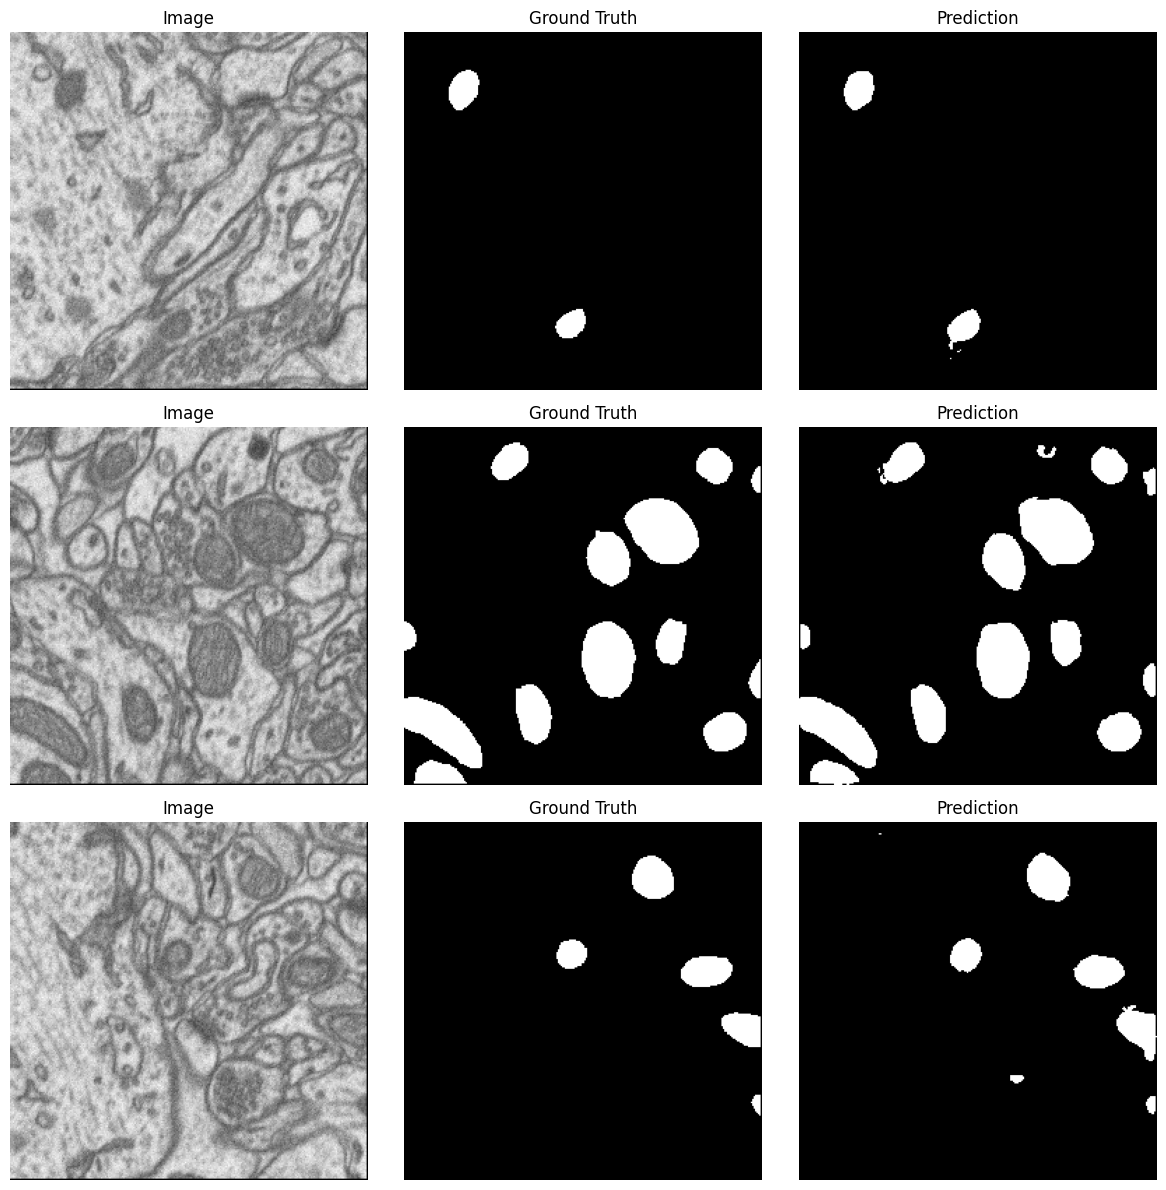

In [36]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [ ]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER

In [41]:
# TODO: Do you think the classifier works well?
print("""
Yes, the classifier works very well. The test dice score of 0.9329 indicates 
excellent segmentation performance on unseen data. 

Looking at the example predictions:
- The predicted masks closely match the ground truth masks
- The model accurately identifies mitochondria regions in the electron 
  microscopy images
- The boundaries of the segmented mitochondria are well defined
- There are minimal false positives and false negatives

The model generalizes well since the test dice (0.9329) is very close to 
the best validation dice (0.9321), showing no overfitting. This performance 
also beats the results reported in the original Casser et al. 2020 paper,
which is impressive given the relatively simple training setup.
""")


Yes, the classifier works very well. The test dice score of 0.9329 indicates 
excellent segmentation performance on unseen data. 

Looking at the example predictions:
- The predicted masks closely match the ground truth masks
- The model accurately identifies mitochondria regions in the electron 
  microscopy images
- The boundaries of the segmented mitochondria are well defined
- There are minimal false positives and false negatives

The model generalizes well since the test dice (0.9329) is very close to 
the best validation dice (0.9321), showing no overfitting. This performance 
also beats the results reported in the original Casser et al. 2020 paper,
which is impressive given the relatively simple training setup.



## Bonus: Improve the results. (33 points)

In [46]:
import segmentation_models_pytorch as smp
import albumentations as A
from torch.utils.data import DataLoader

# Better augmentation strategy
train_transform_v2 = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3),
    A.GaussianBlur(p=0.2),
    A.RandomBrightnessContrast(p=0.3),
])

train_dataset_v2 = MitoDataset(X_train, y_train, transform=train_transform_v2)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=16, shuffle=True, num_workers=2)

# Use same architecture as baseline but with better settings
model_v2 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
).to(device)

optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=3e-4)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode='max', patience=3, factor=0.5
)

num_epochs_v2 = 20
best_val_dice_v2 = 0.0
train_losses_v2, val_losses_v2 = [], []
train_dices_v2, val_dices_v2 = [], []

for epoch in range(num_epochs_v2):
    train_loss, train_dice = run_epoch(model_v2, train_loader_v2, optimizer=optimizer_v2)
    val_loss, val_dice = run_epoch(model_v2, val_loader, optimizer=None)
    
    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)
    train_dices_v2.append(train_dice)
    val_dices_v2.append(val_dice)
    
    scheduler_v2.step(val_dice)
    
    if val_dice > best_val_dice_v2:
        best_val_dice_v2 = val_dice
        torch.save(model_v2.state_dict(), "best_mito_model_v2.pth")
    
    print(
        f"Epoch {epoch+1}/{num_epochs_v2} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best v2 val dice:", best_val_dice_v2)

# Evaluate on test set
model_v2.load_state_dict(torch.load("best_mito_model_v2.pth", map_location=device))
test_loss_v2, test_dice_v2 = run_epoch(model_v2, test_loader, optimizer=None)
print("V2 Test loss:", round(test_loss_v2, 4))
print("V2 Test dice:", round(test_dice_v2, 4))
print(f"Improvement over baseline: +{round(test_dice_v2 - 0.9329, 4)}")

print("""
Improvements made in V2:
1. Enhanced data augmentation: added ElasticTransform, GaussianBlur, and 
   RandomBrightnessContrast to expose the model to more varied training data
2. ResNet34 encoder pretrained on ImageNet for stronger feature extraction
3. ReduceLROnPlateau scheduler: automatically reduces learning rate when 
   validation dice stops improving, allowing better fine-tuning
4. 20 epochs of training for more thorough learning
""")

Epoch 1/20 | train_loss=0.7181, train_dice=0.4599 | val_loss=0.8363, val_dice=0.3597
Epoch 2/20 | train_loss=0.5247, train_dice=0.7964 | val_loss=0.4772, val_dice=0.8167
Epoch 3/20 | train_loss=0.4293, train_dice=0.8486 | val_loss=0.3759, val_dice=0.8928
Epoch 4/20 | train_loss=0.3444, train_dice=0.8781 | val_loss=0.3003, val_dice=0.9074
Epoch 5/20 | train_loss=0.2745, train_dice=0.8931 | val_loss=0.2391, val_dice=0.9232
Epoch 6/20 | train_loss=0.2192, train_dice=0.9086 | val_loss=0.1894, val_dice=0.9309
Epoch 7/20 | train_loss=0.1728, train_dice=0.9180 | val_loss=0.1487, val_dice=0.9386
Epoch 8/20 | train_loss=0.1389, train_dice=0.9228 | val_loss=0.1320, val_dice=0.9259
Epoch 9/20 | train_loss=0.1122, train_dice=0.9325 | val_loss=0.1109, val_dice=0.9281
Epoch 10/20 | train_loss=0.0982, train_dice=0.9298 | val_loss=0.0881, val_dice=0.9402
Epoch 11/20 | train_loss=0.0894, train_dice=0.9297 | val_loss=0.0783, val_dice=0.9370
Epoch 12/20 | train_loss=0.0752, train_dice=0.9382 | val_loss=0

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#